Conectando ao DuckDB...


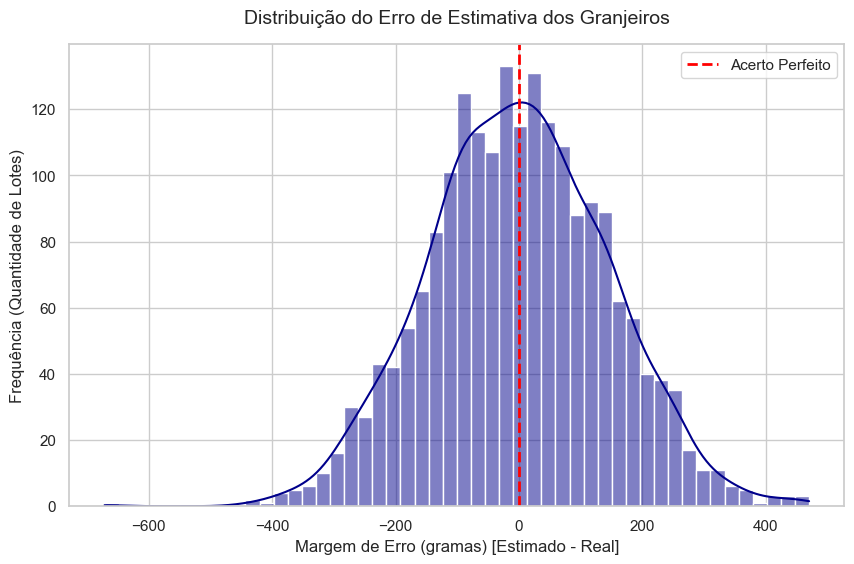

In [7]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional plot style
sns.set_theme(style="whitegrid")

# Connect to DuckDB warehouse
print("Conectando ao DuckDB...")
conn = duckdb.connect("../data/processed/warehouse.duckdb")

# Query: fetch farmer error margins
query = """
    SELECT 
        farmer_id,
        farmer_error_margin_g
    FROM fct_slaughter_batches
"""

# Load query result into Pandas DataFrame
df_error = conn.execute(query).df()

# Plot histogram of estimation errors
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_error,
    x="farmer_error_margin_g",
    bins=50,
    kde=True,
    color="darkblue"
)

# Titles and labels in Portuguese
plt.title("Distribuição do Erro de Estimativa dos Granjeiros", fontsize=14, pad=15)
plt.xlabel("Margem de Erro (gramas) [Estimado - Real]", fontsize=12)
plt.ylabel("Frequência (Quantidade de Lotes)", fontsize=12)

# Add reference line at zero (perfect estimate)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Acerto Perfeito')
plt.legend()
plt.show()

# Close connection
conn.close()



In [ ]:
# CÉLULA INDEPENDENTE PARA O BOXPLOT DE VIÉS INDIVIDUAL
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns# Independent cell for farmer bias boxplot
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Connect and fetch data
conn = duckdb.connect("../data/processed/warehouse.duckdb")
query = """SELECT farmer_id, farmer_error_margin_g FROM fct_slaughter_batches"""
df_error = conn.execute(query).df()
conn.close()  # Always close connection

# Plot boxplot of estimation bias
plt.figure(figsize=(12, 6))

# Select top 10 farmers by batch volume
top_farmers = df_error['farmer_id'].value_counts().nlargest(10).index
df_top_farmers = df_error[df_error['farmer_id'].isin(top_farmers)]

# Create boxplot
sns.boxplot(
    data=df_top_farmers,
    x='farmer_id',
    y='farmer_error_margin_g',
    hue='farmer_id',
    palette='Set2',
    legend=False
)

# Reference lines: perfect estimate and tolerance limits
plt.axhline(y=0, color='red', linestyle='-', linewidth=2, label='Acerto Perfeito (0g)')
plt.axhline(y=100, color='green', linestyle='--', linewidth=2, label='Limite Tolerância (+100g)')
plt.axhline(y=-100, color='green', linestyle='--', linewidth=2, label='Limite Tolerância (-100g)')

# Titles and labels in Portuguese
plt.title("Viés de Estimativa por Granjeiro (Top 10 em Volume de Lotes)", fontsize=14, pad=15)
plt.xlabel("Identificação do Granjeiro", fontsize=12)
plt.ylabel("Margem de Erro (gramas)", fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()


# Configuração visual
sns.set_theme(style="whitegrid")

# 1. Conectar e Buscar Dados
conn = duckdb.connect("../data/processed/warehouse.duckdb")
query = """SELECT farmer_id, farmer_error_margin_g FROM fct_slaughter_batches"""
df_error = conn.execute(query).df()
conn.close() # Sempre feche a conexão

# 2. Analisar o viés específico por Granjeiro (Boxplot)
plt.figure(figsize=(12, 6))

# Selecionar top 10 em volume
top_farmers = df_error['farmer_id'].value_counts().nlargest(10).index
df_top_farmers = df_error[df_error['farmer_id'].isin(top_farmers)]

# Criando o Boxplot
# (Utilizando a nomenclatura correta dos dados sintéticos: farmer_id e farmer_error_margin_g)
sns.boxplot(data=df_top_farmers, x='farmer_id', y='farmer_error_margin_g', hue='farmer_id', palette='Set2', legend=False)

# Desenhando as linhas de meta da empresa (conforme image_2.png)
plt.axhline(y=0, color='red', linestyle='-', linewidth=2, label='Acerto Perfeito (0g)')
plt.axhline(y=100, color='green', linestyle='--', linewidth=2, label='Limite Tolerância (+100g)')
plt.axhline(y=-100, color='green', linestyle='--', linewidth=2, label='Limite Tolerância (-100g)')

# Ajustando Títulos e Rótulos (conforme image_2.png)
plt.title("Viés de Estimativa por Granjeiro (Top 10 em Volume de Lotes)", fontsize=14, pad=15)
plt.xlabel("Identificação do Granjeiro", fontsize=12)
plt.ylabel("Margem de Erro (gramas)", fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()